In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [35]:

df = pd.read_csv("br_ibge_pib_municipio.csv.gz", compression="gzip")
traducao = pd.read_csv("br_bd_diretorios_brasil_municipio.csv")


In [36]:

# Retirando os dados antes de 2021
df = df[df["ano"] == 2021]

# Adicionando o nome da unidade federativa correspondente a cada município
for i in df["id_municipio"]:
    nome_uf = traducao.loc[traducao["id_municipio"] == i, "nome_uf"].values[0]
    df.loc[df["id_municipio"] == i, "nome_uf"] = nome_uf


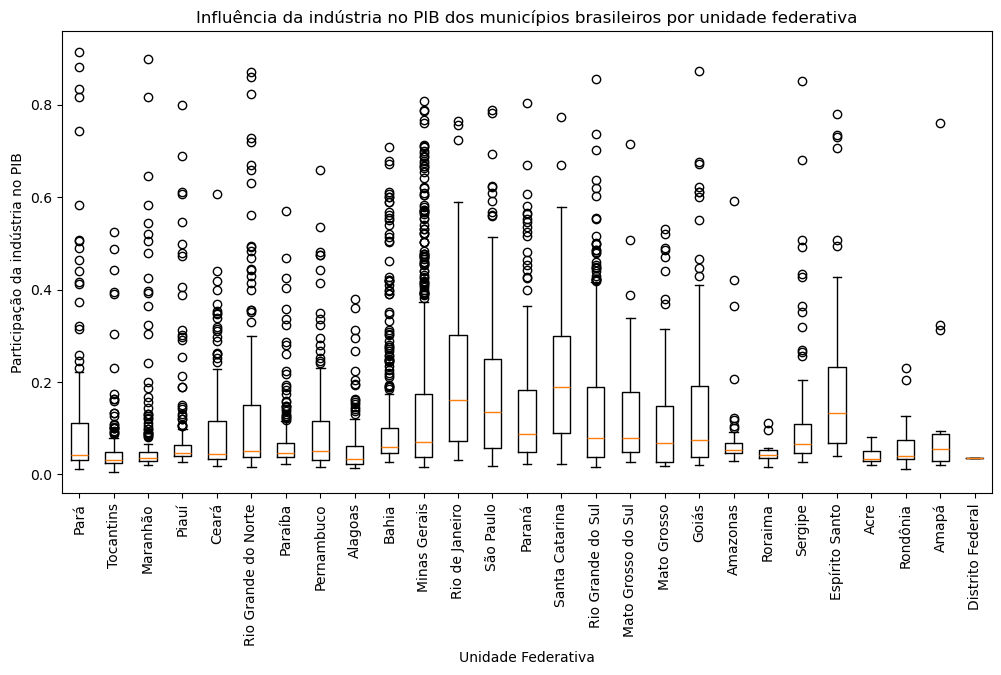

In [5]:

df["va_industria/pib"] = df["va_industria"] / df["pib"]
# Criando um boxplot para analisar a distribuição da participação da indústria no PIB dos municípios brasileiros
df = df.dropna(subset=["va_industria/pib"])
# Removendo outliers negativos
df = df[df["va_industria/pib"] >= 0]
# Usando matplotlib para criar um boxplot da participação da indústria no PIB dos municípios brasileiros comparando cada unidade federativa
plt.figure(figsize=(12, 6))
plt.boxplot([df[df["nome_uf"] == uf]["va_industria/pib"].dropna() for uf in df["nome_uf"].unique()], labels=df["nome_uf"].unique())
plt.xticks(rotation=90)
plt.title('Influência da indústria no PIB dos municípios brasileiros por unidade federativa')
plt.ylabel('Participação da indústria no PIB')
plt.xlabel('Unidade Federativa')
plt.show()



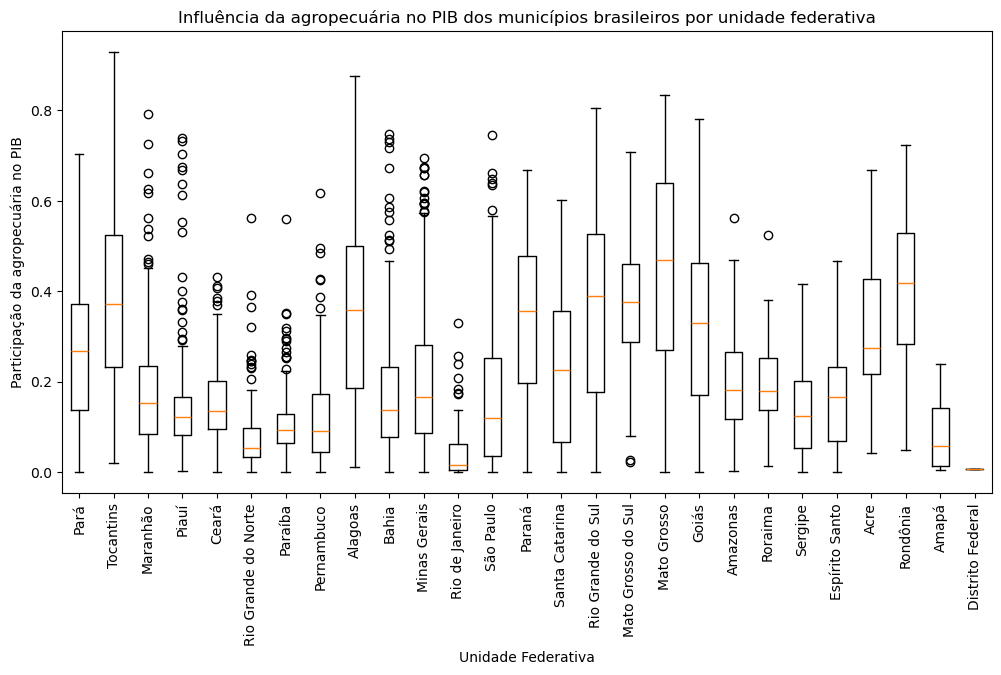

In [6]:
df["va_agropecuaria/pib"] = df["va_agropecuaria"] / df["pib"]
# Criando um boxplot para analisar a distribuição da participação da agropecuária no PIB dos municípios brasileiros
df = df.dropna(subset=["va_agropecuaria/pib"])
# Removendo outliers negativos
df = df[df["va_agropecuaria/pib"] >= 0]
# Usando matplotlib para criar um boxplot da participação da agropecuária no PIB dos municípios brasileiros comparando cada unidade federativa
plt.figure(figsize=(12, 6))
plt.boxplot([df[df["nome_uf"] == uf]["va_agropecuaria/pib"].dropna() for uf in df["nome_uf"].unique()], labels=df["nome_uf"].unique())
plt.xticks(rotation=90)
plt.title('Influência da agropecuária no PIB dos municípios brasileiros por unidade federativa')
plt.ylabel('Participação da agropecuária no PIB')
plt.xlabel('Unidade Federativa')
plt.show()

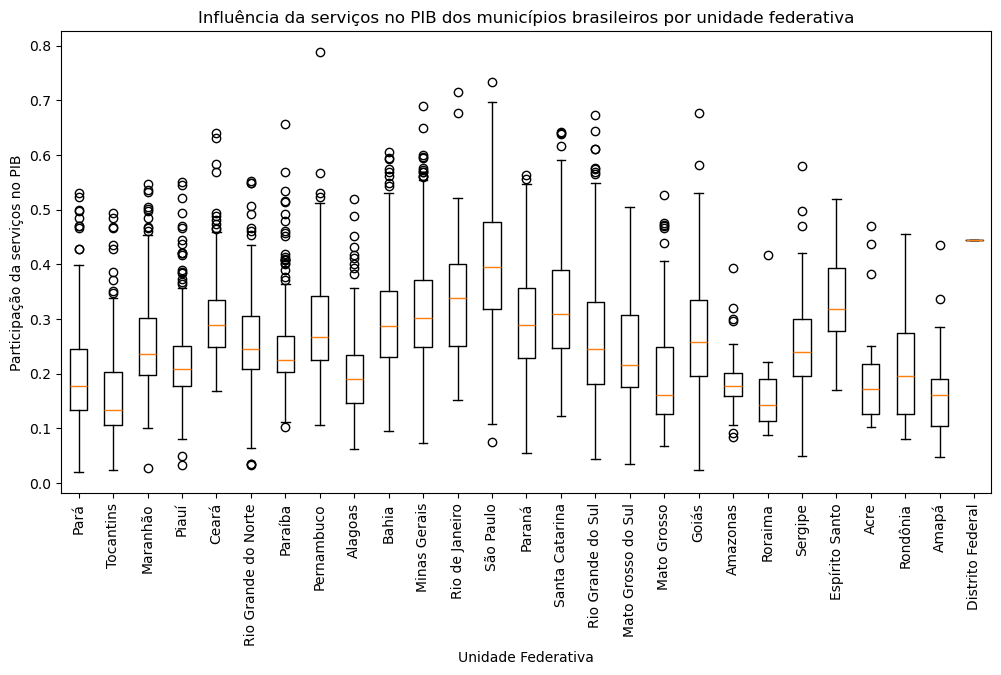

In [7]:
df["va_servicos/pib"] = df["va_servicos"] / df["pib"]
# Criando um boxplot para analisar a distribuição da participação da serviços no PIB dos municípios brasileiros
df = df.dropna(subset=["va_servicos/pib"])
# Removendo outliers negativos
df = df[df["va_servicos/pib"] >= 0]
# Usando matplotlib para criar um boxplot da participação da serviços no PIB dos municípios brasileiros comparando cada unidade federativa
plt.figure(figsize=(12, 6))
plt.boxplot([df[df["nome_uf"] == uf]["va_servicos/pib"].dropna() for uf in df["nome_uf"].unique()], labels=df["nome_uf"].unique())
plt.xticks(rotation=90)
plt.title('Influência da serviços no PIB dos municípios brasileiros por unidade federativa')
plt.ylabel('Participação da serviços no PIB')
plt.xlabel('Unidade Federativa')
plt.show()

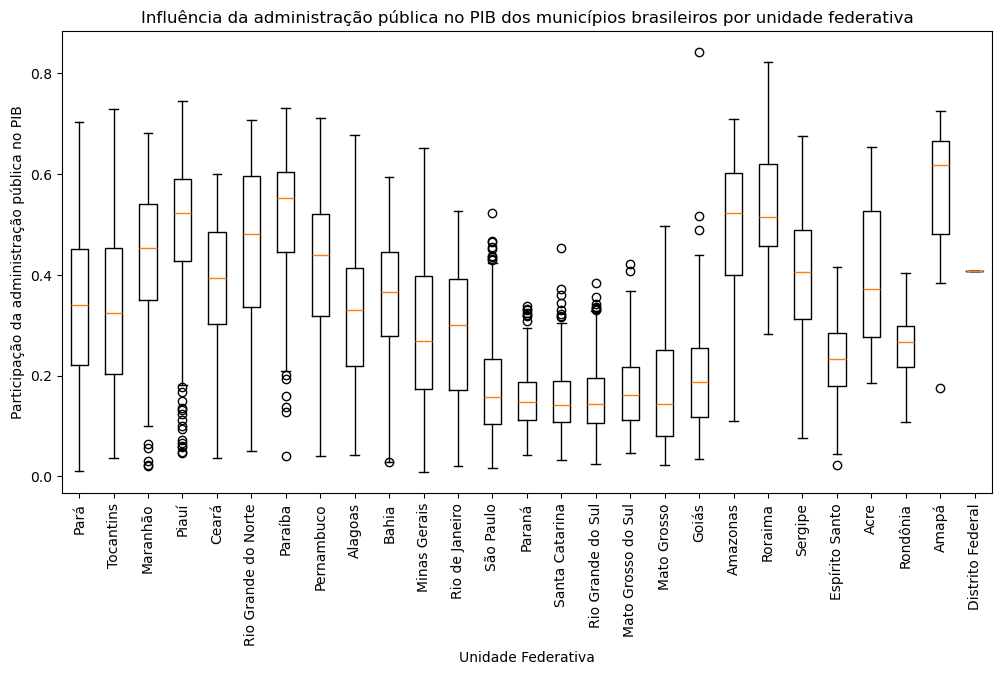

In [38]:
df["va_adespss/pib"] = df["va_adespss"] / df["pib"]
# Criando um boxplot para analisar a distribuição da participação da serviços no PIB dos municípios brasileiros
df = df.dropna(subset=["va_adespss/pib"])
# Removendo outliers negativos
df = df[df["va_adespss/pib"] >= 0]
# Usando matplotlib para criar um boxplot da participação da serviços no PIB dos municípios brasileiros comparando cada unidade federativa
plt.figure(figsize=(12, 6))
plt.boxplot([df[df["nome_uf"] == uf]["va_adespss/pib"].dropna() for uf in df["nome_uf"].unique()], labels=df["nome_uf"].unique())
plt.xticks(rotation=90)
plt.title('Influência da administração pública no PIB dos municípios brasileiros por unidade federativa')
plt.ylabel('Participação da administração pública no PIB')
plt.xlabel('Unidade Federativa')
plt.show()

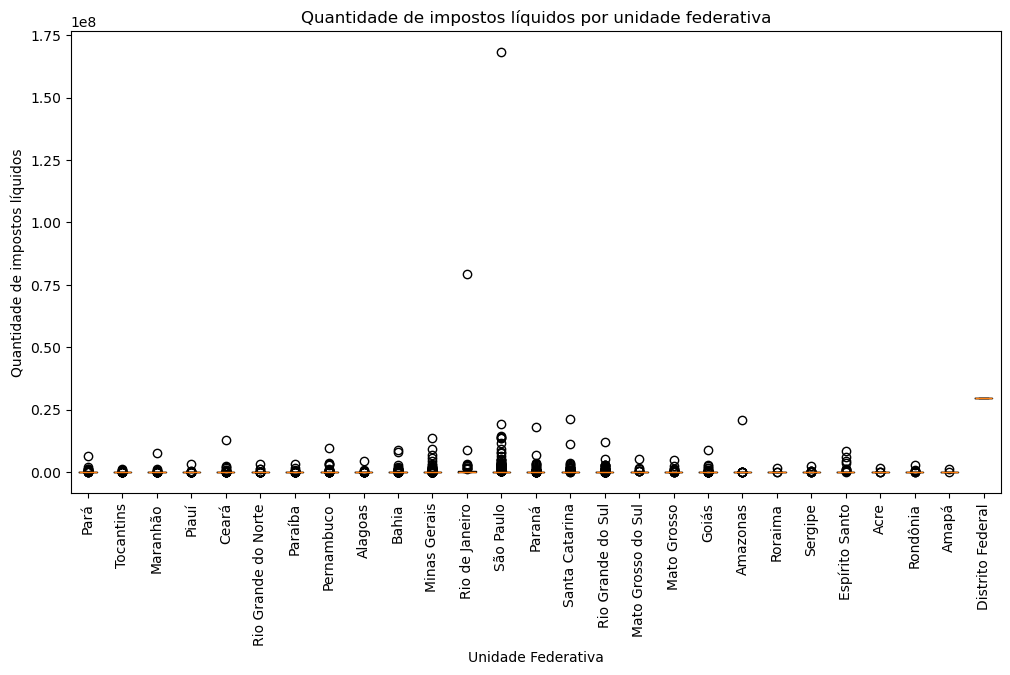

In [8]:

# Criando um boxplot para analisar a quantidade de impostos líquidos por cada UF
df = df.dropna(subset=["impostos_liquidos"])
# Removendo outliers negativos
df = df[df["impostos_liquidos"] >= 0]
# Usando matplotlib para criar um boxplot da quantidade de impostos líquidos por cada UF
plt.figure(figsize=(12, 6))
plt.boxplot([df[df["nome_uf"] == uf]["impostos_liquidos"].dropna() for uf in df["nome_uf"].unique()], labels=df["nome_uf"].unique())
plt.xticks(rotation=90)
plt.title('Quantidade de impostos líquidos por unidade federativa')
plt.ylabel('Quantidade de impostos líquidos')
plt.xlabel('Unidade Federativa')
plt.show()

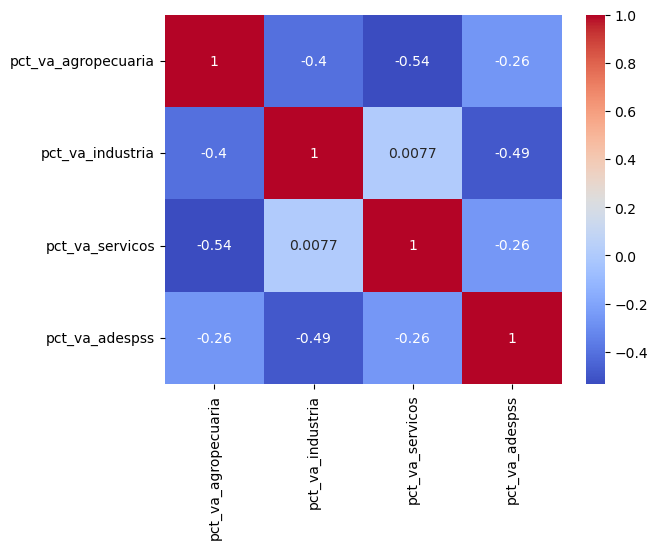

In [9]:
colunas_va = ["va_agropecuaria", "va_industria", "va_servicos", "va_adespss"]

for col in colunas_va:
    df[f"pct_{col}"] = df[col] / df["pib"] * 100

# Colunas para o clustering
features = [f"pct_{col}" for col in colunas_va]


corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

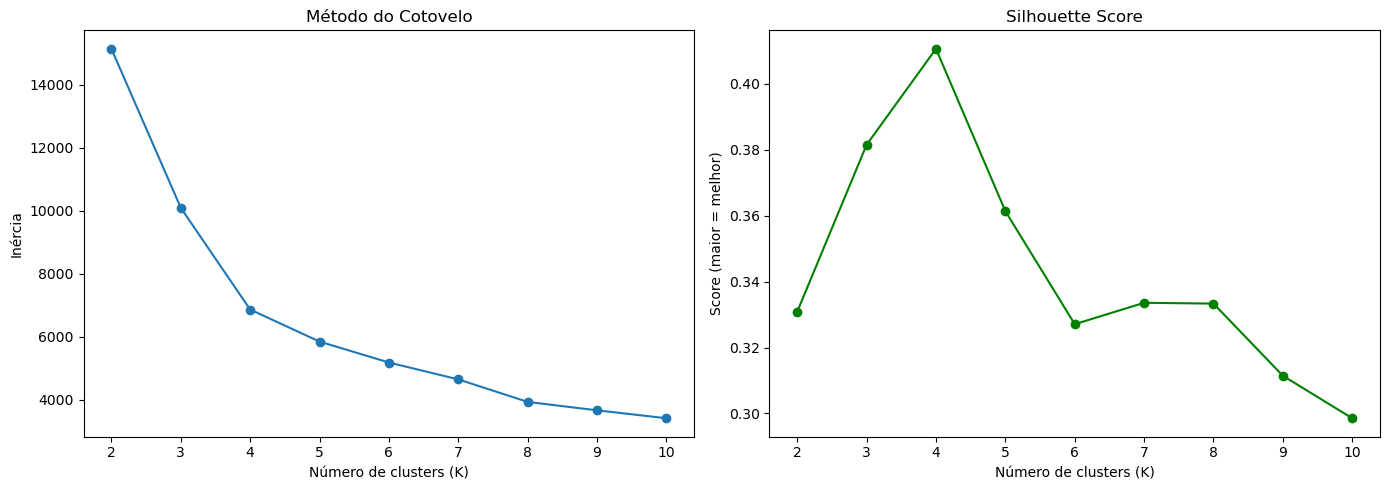

In [28]:
X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker="o")
ax1.set_title("Método do Cotovelo")
ax1.set_xlabel("Número de clusters (K)")
ax1.set_ylabel("Inércia")

ax2.plot(K_range, silhouettes, marker="o", color="green")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Número de clusters (K)")
ax2.set_ylabel("Score (maior = melhor)")

plt.tight_layout()
plt.show()


Silhouette score mostra pico de score em k = 4 e método do cotovelo mostra ponto de inflexão em k = 4

In [29]:

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(X_scaled)
df["cluster"] = kmeans.labels_
# Printando a quantidade de municípios em cada cluster
print(df["cluster"].value_counts())
# Plotando o clustering usando PCA para reduzir a dimensionalidade

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Descobrindo os componentes mais importantes
componentes_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)
print(componentes_df.T.sort_values("PC1", ascending=False))


#                           PC1       PC2
# pct_va_industria     0.540694  0.369468
# pct_va_servicos      0.528741 -0.282331
# pct_va_adespss      -0.346866 -0.706895
# pct_va_agropecuaria -0.554767  0.532994

# Valores demonstram que o componente 1 separa cidades mais industrializadas/urbanas das cidades mais rurais/agropecuárias, enquanto o componente 2 separa cidades mais dependentes do setor público (adespss) das demais. Assim, podemos nomear os eixos como "Urbanização" e "Dependência do setor público", respectivamente.
# O componente 2 demonstra cidades mais rurais com alta dependência do setor público


cluster
1    1783
2    1587
3    1530
0     669
Name: count, dtype: int64
                          PC1       PC2
pct_va_industria     0.540694  0.369468
pct_va_servicos      0.528741 -0.282331
pct_va_adespss      -0.346866 -0.706895
pct_va_agropecuaria -0.554767  0.532994


C:\Users\gpgir\AppData\Local\Temp\ipykernel_1200\647981792.py:18: RuntimeWarning: Mean of empty slice.
  cx = X_pca[df["cluster"] == i, 0].mean()
c:\Users\gpgir\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\gpgir\AppData\Local\Temp\ipykernel_1200\647981792.py:19: RuntimeWarning: Mean of empty slice.
  cy = X_pca[df["cluster"] == i, 1].mean()
posx and posy should be finite values
posx and posy should be finite values


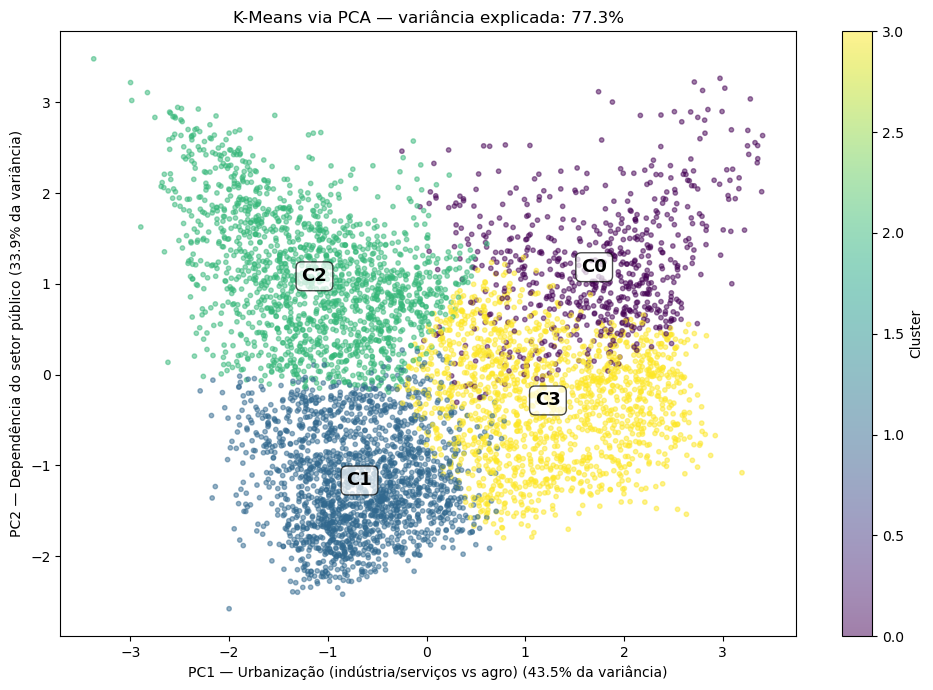

In [15]:
# Variância explicada por cada componente
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 — Urbanização (indústria/serviços vs agro) ({var1:.1f}% da variância)")
plt.ylabel(f"PC2 — Dependência do setor público ({var2:.1f}% da variância)")

for i in range(5):
    cx = X_pca[df["cluster"] == i, 0].mean()
    cy = X_pca[df["cluster"] == i, 1].mean()
    plt.text(cx, cy, f"C{i}", fontsize=13, fontweight="bold", ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.title(f"K-Means via PCA — variância explicada: {var1+var2:.1f}%")
plt.tight_layout()
plt.show()

In [16]:
perfil = df.groupby("cluster")[features].mean().round(2)
print(perfil)

         pct_va_agropecuaria  pct_va_industria  pct_va_servicos  \
cluster                                                           
0                       9.30             42.98            24.33   
1                      15.63              5.50            25.04   
2                      46.30              6.65            21.67   
3                      11.58             14.21            43.11   

         pct_va_adespss  
cluster                  
0                 13.30  
1                 48.80  
2                 20.04  
3                 20.23  


In [19]:
# Ver o PIB mediano de cada cluster
print(df.groupby("cluster")["pib"].median().sort_values(ascending=False))

# Ver quantos municípios tem cada cluster
print(df["cluster"].value_counts().sort_index())

cluster
0    788634.0
3    702862.0
2    220588.0
1    108195.0
Name: pib, dtype: float64
cluster
0     669
1    1783
2    1587
3    1530
Name: count, dtype: int64


### Cluster 0 - Polos industriais
- Demonstra cidades mais dominadas pela indústria
- Maior PIB mediano com menor número de cidades

### Cluster 1 - Cidades dependentes do governo
- Municípios pequenos onde a prefeitura é o principal motor econômico
- Maior grupo, PIB mais baixo 

### Cluster 2 - Cidades rurais e agrícolas
- Agro forte mas economia menos diversificada
- PIB intermediário-baixo 

### Cluster 3 - Cidades mais urbanas
- Cidades com serviços privados desenvolvidos, comércio e serviços financeiros
- PIB alto 


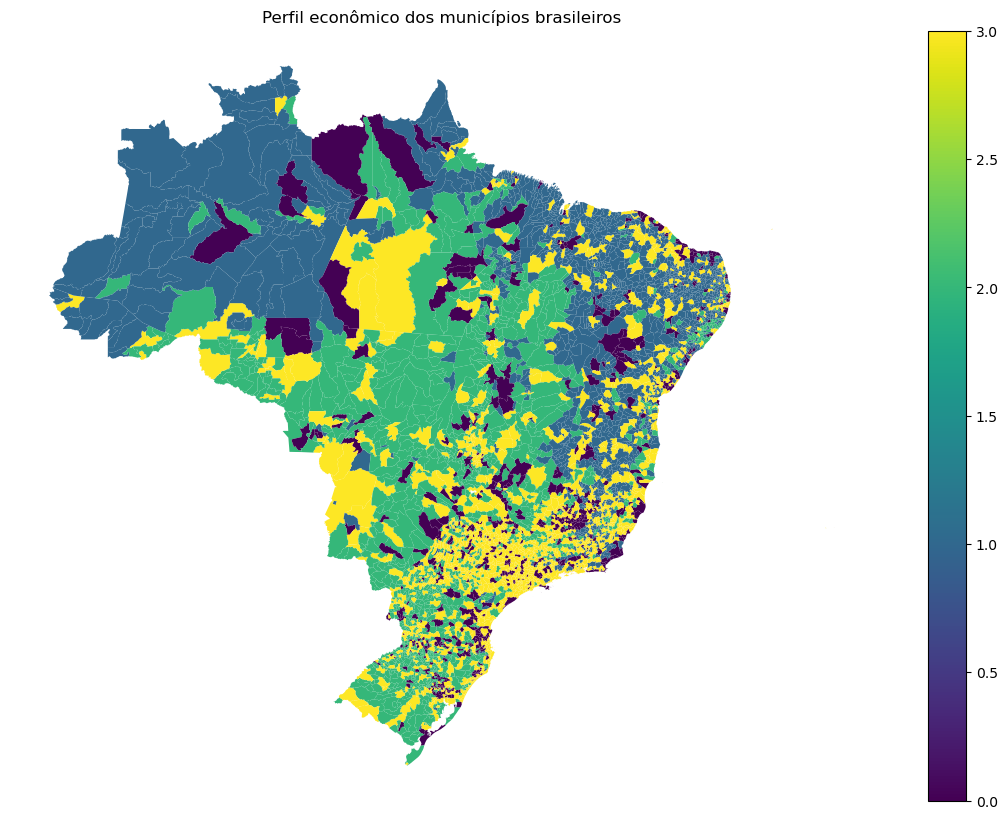

In [20]:
import geopandas as gpd

# Merge do cluster com o shapefile
gdf = gpd.read_file("BR_Municipios_2021.shp")
# Padronizar os dois para 7 dígitos
gdf["CD_MUN"] = gdf["CD_MUN"].astype(str).str[:7]  # manter 7 dígitos
df["id_municipio"] = df["id_municipio"].astype(str).str[:7]

# Fazer o merge
gdf_merged = gdf.merge(
    df[["id_municipio", "cluster"]],
    left_on="CD_MUN",
    right_on="id_municipio",
    how="left"
)


# Plotar
gdf_merged.plot(
    column="cluster",
    cmap="viridis",
    legend=True,
    figsize=(14, 10)
)
plt.title("Perfil econômico dos municípios brasileiros")
plt.axis("off")
plt.show()

In [ ]:
import folium
import json
import geopandas as gpd
import os

# Merge do cluster com o shapefile
gdf = gpd.read_file("BR_Municipios_2021.shp")
# Padronizar os dois para 7 dígitos
gdf["CD_MUN"] = gdf["CD_MUN"].astype(str).str[:7]  # manter 7 dígitos
df["id_municipio"] = df["id_municipio"].astype(str).str[:7]

# Fazer o merge
gdf_merged = gdf.merge(
    df[["id_municipio", "cluster"]],
    left_on="CD_MUN",
    right_on="id_municipio",
    how="left"
)
# Simplificação mais agressiva
gdf_merged["geometry"] = gdf_merged["geometry"].simplify(tolerance=0.05, preserve_topology=True)

# Converter para GeoJSON explicitamente (mais leve que passar o GeoDataFrame direto)
geojson_data = json.loads(gdf_merged.to_json())

# Recriar o mapa
m = folium.Map(location=[-15, -55], zoom_start=4, tiles="CartoDB positron")

folium.GeoJson(
    geojson_data,
    name="Clusters",
    style_function=lambda feature: {
        "fillColor": ["#440154", "#31688e", "#35b779", "#fde725", "#ff7f00"][
            int(feature["properties"]["cluster"])
            if feature["properties"]["cluster"] is not None
            else 0
        ],
        "color": "black",
        "weight": 0.3,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["NM_MUN", "cluster"],
        aliases=["Município:", "Cluster:"],
        localize=True,
        sticky=True
    )
).add_to(m)

m.save("mapa_clusters.html")
print("Abra o arquivo mapa_clusters.html no seu navegador!")
tamanho = os.path.getsize("mapa_clusters.html") / (1024 * 1024)
print(f"Tamanho: {tamanho:.1f} MB")

Abra o arquivo mapa_clusters.html no seu navegador!
Tamanho: 2.7 MB


In [22]:
from sklearn.metrics import pairwise_distances_argmin_min

# Índices dos municípios mais próximos de cada centróide
mais_proximos, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_scaled)

print("Municípios mais representativos de cada cluster:\n")
for cluster_id, idx in enumerate(mais_proximos):
    municipio = df.iloc[idx]["id_municipio"]
    municipio_str = str(municipio)

    trad = traducao.loc[traducao["id_municipio"].astype(str) == municipio_str, "nome"]
    if trad.empty:
        print(f"Cluster {cluster_id}: id {municipio}, nome não encontrado")
        continue

    nome_municipio = trad.iloc[0]
    df.loc[df["id_municipio"] == municipio, "nome"] = nome_municipio
    print(f"Cluster {cluster_id}: id {municipio}, nome {nome_municipio}")
    

Municípios mais representativos de cada cluster:

Cluster 0: id 4316758, nome Santa Clara do Sul
Cluster 1: id 2408508, nome Ouro Branco
Cluster 2: id 3512605, nome Coronel Macedo
Cluster 3: id 2301901, nome Barbalha
